## Why Log-Normal for Prices, Normal for Returns

Stock prices move **multiplicatively**, not additively — each day's price is 
the previous price scaled by a growth factor (e.g., ×1.03 or ×0.98).

Taking the log of the price path converts this multiplication into addition:

    log(P_N) = log(P_0) + log(r_1) + log(r_2) + ... + log(r_N)

This turns the price path into a **sum of many random variables** (the log-returns). 
By the Central Limit Theorem, a sum of many independent random variables tends 
toward a normal distribution — regardless of the underlying distribution of each 
individual term.

So:
- **log(P_N) is approximately Normal** → which means **P_N is Log-Normal**
- **Log-returns are the normal piece** — the natural unit this math operates on

This also aligns with a practical constraint: **stock prices can't go negative**, 
but returns can be negative. The log-normal distribution respects this — it's 
strictly positive — while the normal distribution (used for returns/log-returns) 
allows negative values naturally.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## What This Simulation Represents

This is **synthetic stock price data** — a simulated price path across 252 
trading days (one trading year).

At each step, we draw a random "change" from a normal distribution (mean=0, 
std=1) and add it to the running price. The cumulative sum of these random 
changes produces a path that visually resembles a real stock price chart — 
drifting, reversing, trending — even though the underlying process is pure 
randomness with no signal or skill involved.

Running this with multiple random seeds shows how **identical rules can 
produce wildly different-looking outcomes** — a key intuition for why price 
charts alone can be misleading; apparent "trends" can emerge from noise.

Seed: 0
Mean: 0.03666935909441745
Variance: 1.0309016821487798
Skew: -0.09690427469372644
Kurtosis (excess): -0.263205447302465

Seed: 1
Mean: 0.03131131497064092
Variance: 0.9867561369301882
Skew: 0.1373744297962714
Kurtosis (excess): -0.4715981915330838

Seed: 2
Mean: 0.07343345620717702
Variance: 0.9002815111732072
Skew: 0.05121766167941607
Kurtosis (excess): -0.1741794453358656

Seed: 3
Mean: -0.01913393076080326
Variance: 1.1192138204326278
Skew: 0.19696254030364563
Kurtosis (excess): 0.6351629132288807

Seed: 4
Mean: 0.02661450340986277
Variance: 1.0249855200768045
Skew: 0.044452803947896184
Kurtosis (excess): 0.0381546530375898

Seed: 5
Mean: 0.05404626147120228
Variance: 0.9739288253050592
Skew: 0.15354720057456614
Kurtosis (excess): -0.3637590961110524

Seed: 6
Mean: 0.0003408172191120569
Variance: 0.9251996567001332
Skew: 0.08002825496663006
Kurtosis (excess): 0.011858511113998826

Seed: 7
Mean: 0.01637099950582136
Variance: 0.9205070158311139
Skew: -0.20587284801127442
Kurto

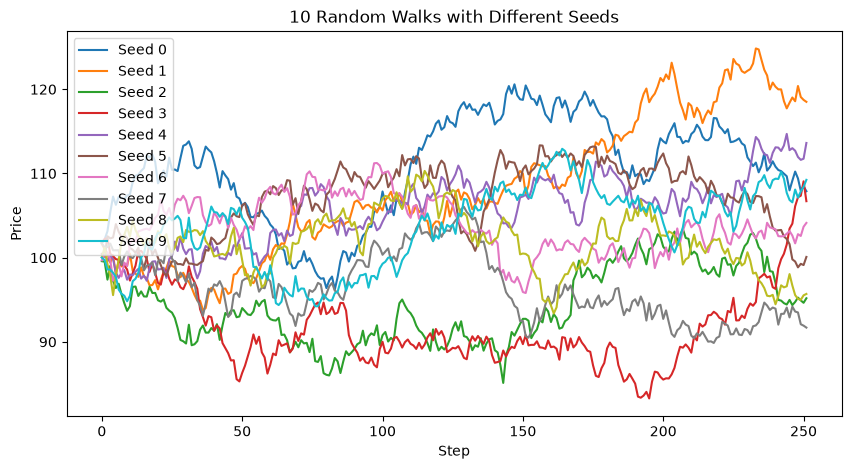

In [5]:
start_price = 100
n_steps = 252
plt.figure(figsize=(10, 5))

for seed in range(10):
    np.random.seed(seed)

    mean_val = np.mean(random_changes)
    var_val = np.var(random_changes)
    skew_val = stats.skew(random_changes)
    kurt_val = stats.kurtosis(random_changes)

    print(f"Seed: {seed}")
    print(f"Mean: {mean_val}")
    print(f"Variance: {var_val}")
    print(f"Skew: {skew_val}")
    print(f"Kurtosis (excess): {kurt_val}\n")

    random_changes = np.random.normal(0, 1, n_steps)
    prices = start_price + np.cumsum(random_changes)

    plt.plot(prices, label=f"Seed {seed}")

plt.xlabel("Step")
plt.ylabel("Price")
plt.title("10 Random Walks with Different Seeds")
plt.legend()
plt.show()

## Interpreting Mean, Variance, Skew, Kurtosis

These statistics were computed on the **step changes** (not the price path 
itself), since the step changes are the actual random draws from our 
distribution.

- **Mean ≈ 0** — matches the distribution we specified (normal, mean=0)
- **Variance ≈ 1** — matches the std=1 we set (variance = std²)
- **Skew ≈ 0** — confirms the distribution is symmetric, as expected from 
  a true normal distribution
- **Excess Kurtosis ≈ 0** — confirms the tails match a normal distribution 
  exactly, with no unusual fat-tail behavior

These results act as a **sanity check**: they confirm the random number 
generator is behaving as expected, and our simulation correctly reflects 
a normal-distribution-based random walk.

This will be an important contrast later — real stock returns typically 
show **positive excess kurtosis** (fatter tails, more extreme moves than 
a normal distribution predicts), unlike this clean synthetic simulation.